# Swipe-next UI assumption

![Swipe-next UI](../img/swipe_next.png)

This notebook studies the Expedia ranking data under a **swipe-next behavior** assumption.

The idea is that the user sees **one hotel at a time** and must actively move forward to inspect the next one. Because of that, later positions are only meaningful if the user actually reached them by passing on the earlier ones.

For this notebook, the key function is `get_swipe_next_dataset`.  
It is the right transformation because it rebuilds the data as a **sequential browse flow**: it keeps only sessions with a click, finds the first click, and keeps only the hotels up to that point. This matches the idea that once the user clicks, the meaningful sequential path ends there.

So the purpose of this notebook is to analyze the ranking as a **reach-until-first-click** experience rather than as a fully visible page.

## Setup

In [1]:
%cd ..
%load_ext autoreload
%autoreload 2

/Users/cesarchalco/Documents/personal/articles/003 - dealing with position bias for tap propensity


In [2]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from unbiastap import (
    load_config,
    load_expedia,
    get_swipe_next_dataset,
    train_test_split_by_session,
)

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

In [4]:
CONFIG_PATH = os.path.join("config", "constants.yaml")
CONFIG = load_config(CONFIG_PATH)

DATA_PATH = os.path.join(
    CONFIG["general"]["data_dir"], CONFIG["general"]["raw_file"]
)

TARGET = CONFIG["target"]["click_col"]
FEATURES = CONFIG["features"]["columns"]

SEED = CONFIG["general"]["random_seed"]
MAX_POSITION = CONFIG["ranking"]["max_position"]

## Fetch Data

In [5]:
df = load_expedia(DATA_PATH, max_position=MAX_POSITION)

In [6]:
df.shape

(9914326, 17)

In [7]:
swipe_next_df = get_swipe_next_dataset(df)

In [8]:
swipe_next_df.shape

(2923423, 18)

## Naive approach

In [9]:
train_df, test_df = train_test_split_by_session(
    df=swipe_next_df, test_size=0.2, random_seed=SEED
)

**Training population:** sessions from `swipe_next_df` that had at least one click, keeping only items up to and including the first clicked item — the sequential evaluation path the user actually took. **Label `click_bool`:** 1 = user clicked this item and ended the session, 0 = user evaluated this item, passed on it, and continued browsing. No position bias correction — the model learns click probability as observed, position signal included implicitly.

In [10]:
from xgboost import XGBClassifier

model = XGBClassifier(seed=SEED)
model.fit(train_df[FEATURES], train_df[TARGET])

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [11]:
naive_y_pred = model.predict_proba(test_df[FEATURES])[:, 1]

In [12]:
test_df["naive_score"] = naive_y_pred

In [13]:
from unbiastap.evaluation.ranking.metrics import ndcg_at_k, debiased_ndcg_at_k
from unbiastap.evaluation.ranking.plots import (
    plot_score_vs_position,
    plot_ctr_vs_position,
)

naive_ndcg = ndcg_at_k(
    test_df,
    query_col="srch_id",
    label_col=TARGET,
    score_col="naive_score",
    k=10,
)

print(f"NDCG@10: {naive_ndcg:.2f}")

NDCG@10: 0.66


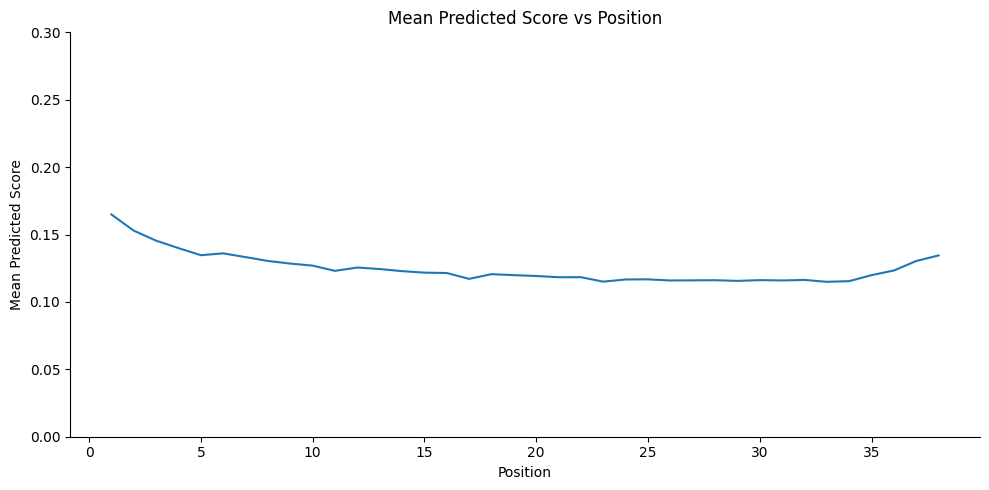

In [14]:
fig = plot_score_vs_position(
    test_df, position_col="position", score_col="naive_score", ylim=(0.0, 0.3)
)

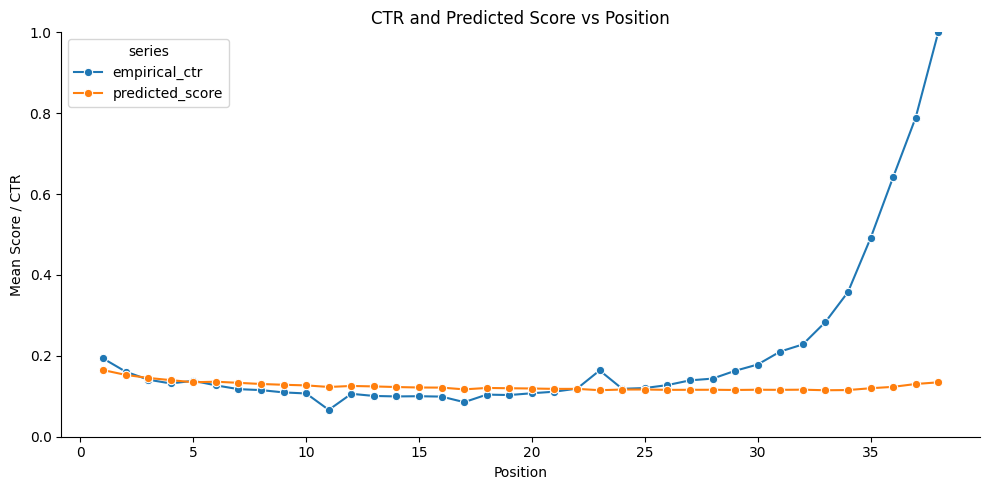

In [15]:
fig = plot_ctr_vs_position(
    test_df,
    position_col="position",
    label_col=TARGET,
    score_col="naive_score",
    ylim=(0.0, 1.0),
)

In [16]:
position_summary = (
    test_df.groupby("position")
    .agg(
        ctr=(TARGET, "mean"),
        avg_naive_score=("naive_score", "mean"),
        n_rows=(TARGET, "size"),
    )
    .sort_index()
)

position_summary[["ctr", "avg_naive_score"]] = position_summary[
    ["ctr", "avg_naive_score"]
].round(2)

position_summary = position_summary.T

position_summary

position,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38
ctr,0.19,0.16,0.14,0.13,0.14,0.13,0.12,0.12,0.11,0.11,0.07,0.11,0.10,0.10,0.10,0.10,0.09,0.10,0.10,0.11,0.11,0.12,0.16,0.12,0.12,0.13,0.14,0.14,0.16,0.18,0.21,0.23,0.28,0.36,0.49,0.64,0.79,1.00
avg_naive_score,0.16,0.15,0.15,0.14,0.13,0.14,0.13,0.13,0.13,0.13,0.12,0.13,0.12,0.12,0.12,0.12,0.12,0.12,0.12,0.12,0.12,0.12,0.12,0.12,0.12,0.12,0.12,0.12,0.12,0.12,0.12,0.12,0.11,0.12,0.12,0.12,0.13,0.13
n_rows,79728.00,64300.00,53956.00,46348.00,470.00,40206.00,35096.00,30969.00,27386.00,24401.00,226.00,21771.00,19504.00,17534.00,15796.00,14214.00,117.00,12792.00,11466.00,10287.00,9186.00,8167.00,61.00,7189.00,6346.00,5578.00,4872.00,4190.00,3589.00,3002.00,2469.00,1954.00,1506.00,1082.00,699.00,357.00,128.00,27.00


Given the swipe-next behavior, the $P(see|position)$ can't be computed as the fraction of impressions at each position, because impressions at later positions only happen if the user reached them by passing on the earlier ones so every item has a reached impression.

For that reason, we will compute the chance of been seen from the logs directly.

> Another way to do this is to compute the chance of been seen as the fraction of sessions that reached that position and in that way you don't need to rely on the other dataset to compute the chance of been seen :)

In [17]:
first_click_pos = (
    df[df["click_bool"] == 1].groupby("srch_id")["position"].min()
)

view_propensity = (
    df[["srch_id", "position"]]
    .drop_duplicates()
    .merge(first_click_pos.rename("first_click_pos"), on="srch_id", how="left")
    .assign(
        reached=lambda x: (x["position"] <= x["first_click_pos"]).astype(int)
    )
    .groupby("position")["reached"]
    .mean()
    .reset_index()
    .rename(columns={"reached": "view_propensity"})
)

In [18]:
view_propensity.head()

,position,view_propensity
0,1,0.999942
1,2,0.807017
2,3,0.678750
3,4,0.599244
4,5,0.122742


The result shows a monotonic decay — position 1 has propensity 1.0 by definition (every session starts there), and it drops as we go further because more sessions end in a click before reaching those positions.

Sessions with no clicks get `NaN` for `first_click_pos`. Since `position <= NaN` is always False, every position in those sessions gets `reached = 0` — meaning we treat them as if nothing was seen. This is a reasonable assumption: without a click, we have no proof the user ever scrolled past any result.

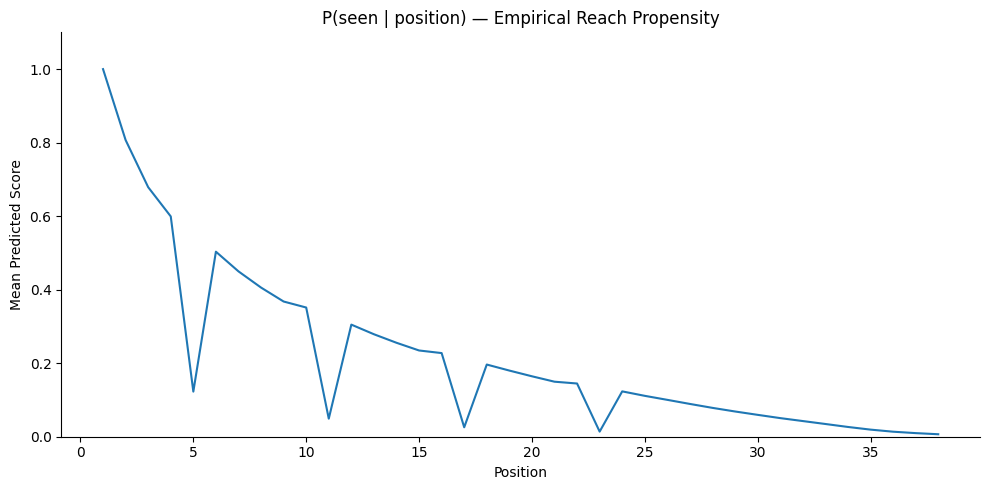

In [19]:
fig = plot_score_vs_position(
    view_propensity,
    position_col="position",
    score_col="view_propensity",
    title="P(seen | position) — Empirical Reach Propensity",
    ylim=(0.0, 1.1),
)

Let’s jump ahead a bit and apply a debiased version of NDCG that basically reweights the relevance by the inverse of the propensity.

In [20]:
test_df = test_df.merge(view_propensity, on="position", how="left")
train_df = train_df.merge(view_propensity, on="position", how="left")

In [21]:
naive_debiased_ndcg = debiased_ndcg_at_k(
    test_df,
    query_col="srch_id",
    label_col=TARGET,
    score_col="naive_score",
    propensity_col="view_propensity",
    k=10,
)

print(f"Standard NDCG@10  (naive): {naive_ndcg:.4f}")
print(f"Debiased NDCG@10  (naive): {naive_debiased_ndcg:.4f}")

Standard NDCG@10  (naive): 0.6587
Debiased NDCG@10  (naive): 0.6587


## How to apply IPS here?

IPS weights are basicallly $w_i = \frac{1}{P(\text{position}=i)}$, so the first step is to compute the position distribution, which is the denominator of the IPS formula.

There are two ways to compute the IPS weights:

1. Direcly from logs: we can compute the position distribution from the logs and then take the inverse to get the weights.
2. Fit a decay model: we can fit a model to the position distribution, such as an exponential decay, and then use the fitted model to compute the weights.

But as any other ML scenario, we have a tradeoff here, depicted in the following table:
| | Empirical | Parametric decay |
|---|---|---|
| **Bias** | Low, no distributional assumption | High if the model family is wrong |
| **Variance** | High at sparse positions (tail) | Low, smooth by construction |
| **Extrapolation** | Cannot go beyond served positions | Yes, closed form for any \(k\) |
| **Interpretability** | A direct table of observed values | Parameter(s) summarizes the curve |
| **Fit effort** | Zero, only count impressions | Requires family choice, fitting, and validation |
| **Cold start** | Fails immediately | Graceful, prior works until data arrives |


## Empirical IPS model

We go with the empirical approach: use the reach-based $P(\text{seen} | k)$ we computed from the logs as the IPS denominator. No parametric assumption, no decay model to tune — just the observed position distribution.

The weight for each training sample at position $k$ is:

$$w_i = \frac{1}{P(\text{seen} | k)}$$

Samples at positions with low reach probability receive a higher weight, compensating for the fact that items at later positions are underrepresented in the training data relative to how often they would appear in a position-unbiased world.

In [22]:
from unbiastap import IPSXGBoostAdapter, IPSXGBoostConfig

config = IPSXGBoostConfig(
    label_column=TARGET,
    features=FEATURES,
    exposure_propensity_column="view_propensity",
    weight_clip_percentile=98.31,  # no weight clipping
)

ips_model = IPSXGBoostAdapter(config)

Before fitting, it's worth checking that the configured clip percentile sits in a stable region. A stable region is where the clip threshold value barely changes as the percentile moves — meaning the tail of the weight distribution is thin and the choice of percentile is not overly sensitive. If the curve is steep at the configured percentile, consider moving it left until it flattens.

### How to choose the clip percentile

The stability plot shows *where* the weight distribution has a heavy tail — but it doesn't give you a number to pick. For that you need a criterion based on **Effective Sample Size (ESS)**:

$$\text{ESS}(c) = \frac{\left(\sum_i \min(w_i, c)\right)^2}{\sum_i \min(w_i, c)^2}$$

ESS measures the equivalent number of unweighted observations your clipped sample is worth. When all weights are equal, $\text{ESS} = n$ (no information lost). When one sample dominates, $\text{ESS} \to 1$ (catastrophic variance). The ratio $\text{ESS}(c)/n \in (0, 1]$ is the fraction of statistical power you retain after clipping at $c$.

**Programmatic objective:** sweep $c$ across the weight distribution and find the smallest $c$ such that $\text{ESS}(c)/n \geq \tau$:

$$c^* = \min \left\{ c : \frac{\text{ESS}(c)}{n} \geq \tau \right\}$$

A practical starting point is $\tau = 0.3$ — you accept losing up to 70% of effective sample size to control variance. Below $\tau$, a handful of samples dominate the gradient and the model is fitting noise. Above it, the bias introduced by clipping is worth the variance reduction.

This maps directly to a `ClipSelector` class with a `fit(weights, tau)` method that: (1) builds a grid of candidate clip values from the weight distribution, (2) computes ESS at each, (3) returns the smallest $c$ where ESS/$n \geq \tau$. The stability plot is then a *diagnostic* on top of that — it confirms the chosen $c$ sits in a flat region so small perturbations in the data won't destabilize the threshold.

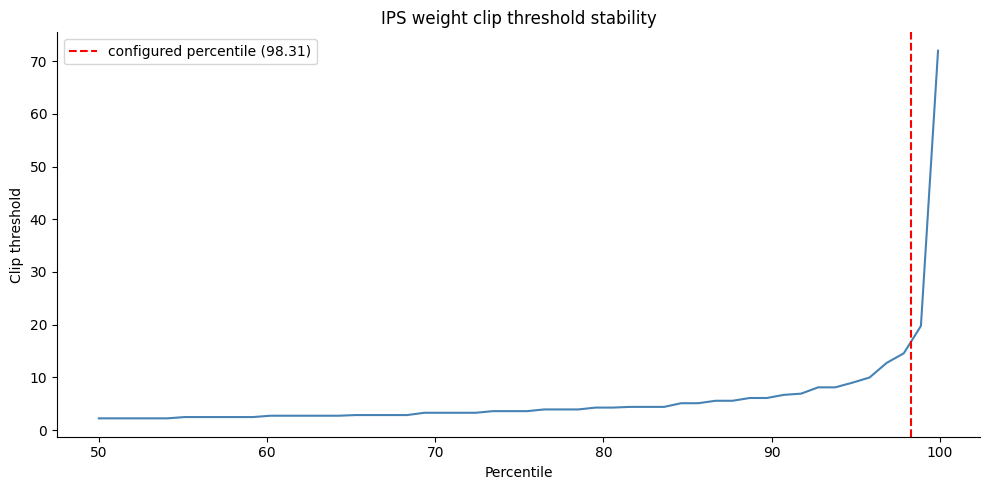

In [23]:
fig = ips_model.plot_clip_stability(train_df, n_points=50)

Let's train first with no clipping at all and then apply the clipping to see how it affects the results.

In [24]:
ips_model.fit(train_df)

Clipping 33608 IPS weights (1.4%) above the 98.3 percentile (clip value: 16.8033). Large clipping ratios may indicate poor propensity score calibration.


In [25]:
test_df["ips_score"] = ips_model.predict(test_df)

In [26]:
ips_ndcg = ndcg_at_k(
    test_df, query_col="srch_id", label_col=TARGET, score_col="ips_score", k=10
)

ips_debiased_ndcg = debiased_ndcg_at_k(
    test_df,
    query_col="srch_id",
    label_col=TARGET,
    score_col="ips_score",
    propensity_col="view_propensity",
    k=10,
)

print(f"{'Model':<20} {'NDCG@10':>10} {'Debiased NDCG@10':>18}")
print("-" * 50)
print(f"{'Naive':<20} {naive_ndcg:>10.4f} {naive_debiased_ndcg:>18.4f}")
print(f"{'IPS':<20} {ips_ndcg:>10.4f} {ips_debiased_ndcg:>18.4f}")

Model                   NDCG@10   Debiased NDCG@10
--------------------------------------------------
Naive                    0.6587             0.6587
IPS                      0.6614             0.6614


The two metrics tell different stories on purpose. **Standard NDCG** rewards whichever model surfaces clicked items first — it doesn't know or care that position 1 clicks are inflated. **Debiased NDCG** adjusts relevance by $1/P(\text{seen}|k)$ before scoring, so items at hard-to-reach positions carry more weight. A model that genuinely learned item quality should improve on the debiased metric even if it looks similar or worse on the standard one.

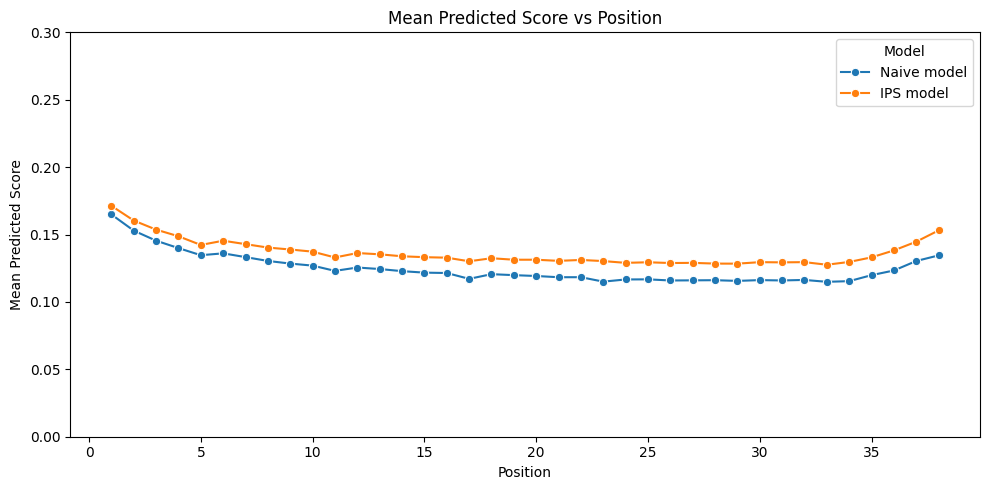

In [27]:
score_by_position = (
    test_df.groupby("position", as_index=False)[["naive_score", "ips_score"]]
    .mean()
    .melt(
        id_vars="position",
        var_name="model",
        value_name="mean_predicted_score",
    )
)

score_by_position["model"] = score_by_position["model"].map(
    {
        "naive_score": "Naive model",
        "ips_score": "IPS model",
    }
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=score_by_position,
    x="position",
    y="mean_predicted_score",
    hue="model",
    marker="o",
    ax=ax,
)

ax.set_title("Mean Predicted Score vs Position")
ax.set_ylim(0.0, 0.3)
ax.set_xlabel("Position")
ax.set_ylabel("Mean Predicted Score")
ax.legend(title="Model")
plt.tight_layout()

The IPS model's it's pretty similar to the naive model and the naive and debiased NDCG@10 are pretty close. This suggests that the position bias is not very strong in this dataset. Nevertheless, the IPS model is slightly better on the debiased NDCG, which indicates that it may have learned a bit more about item quality rather than just position.  

In addition, the IPS model estimates a higher probability of click overall, which is a good sign that it's learning something meaningful rather than just overfitting to position bias.

Now, lelt's use the `ClipSelector` to find the optimal clipping threshold for the IPS weights and see how it affects the results.

> Note that we will clip up to 0.5 of the effective sample size, which means we can afford to clip quite aggressively if needed without losing too much statistical power.

In [28]:
from unbiastap import ClipSelector, ClipSelectorConfig

clip_config = ClipSelectorConfig(
	n_grid_points=200,
    tau=0.5
)

ips_weights = 1 / np.clip(train_df["view_propensity"].to_numpy(), 1e-6, None)

clip_selector = ClipSelector(clip_config)
clip_selector.fit(weights=ips_weights) 

In [29]:
print(f"Optimal clipping value: {clip_selector.clip_value_:.2f}")
print(f"Optimal clipping percentile: {clip_selector.clip_percentile_:.2f}")

Optimal clipping value: 16.80
Optimal clipping percentile: 98.31


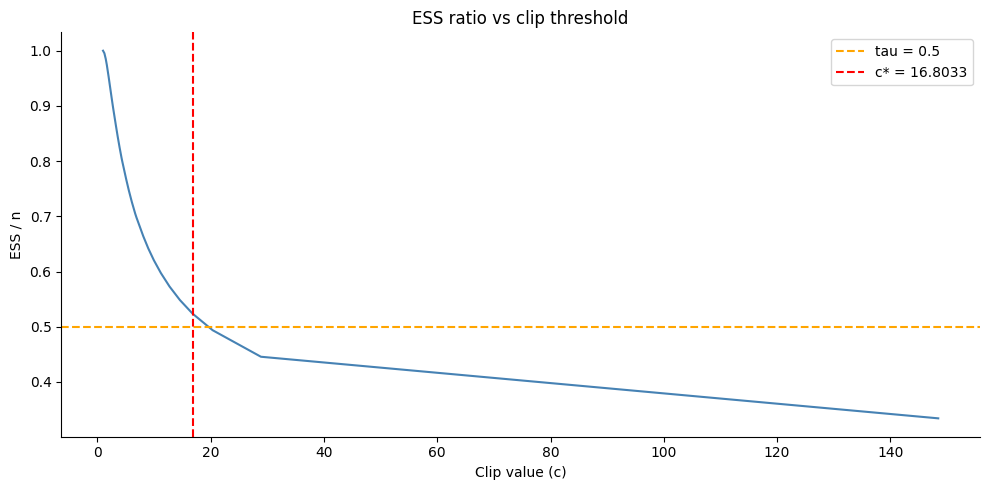

In [30]:
fig = clip_selector.plot_ess_curve()

## Parametric decay propensity

The empirical $P(\text{seen}|k)$ is exact where the data is dense but noisy at the tail — positions 30+ have few sessions reaching them, so the estimates are unreliable. An alternative is to model the decay parametrically.

Under the swipe-next model, if $d$ is the probability of continuing to the next item after not clicking (the sequential dropout rate), then:

$$P(\text{seen} | k) = d^{k-1}$$

> This formula comes from the inuition of the combination of bayes theorem, the chain rule, the pick of the beta distribution as a prior for the dropout rate and the bernoulli distribution as the likelihood of the click at each position.

Position 1 always has propensity 1, and each subsequent position discounts by $d$. This is a strong assumption — it implies the dropout rate is constant across positions — but it has very low variance and degrades gracefully in the tail where we have no data.

Before committing to a value of $d$, let's visualize the full family of decay curves across the valid range. This helps develop intuition for how sensitive the propensity estimates are to the choice of $d$ — and where the empirical estimate should fall relative to the parametric family.

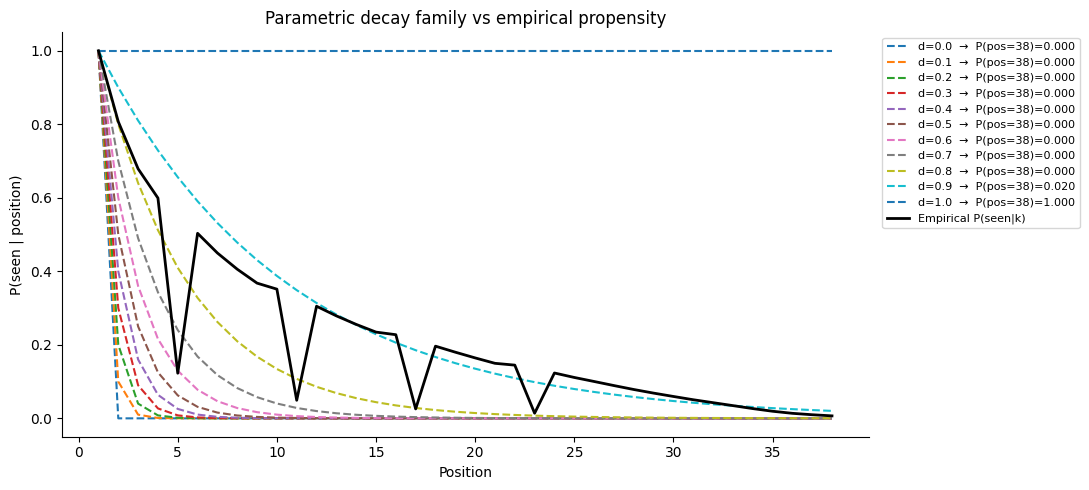

In [31]:
positions = list(range(1, MAX_POSITION + 1))

fig, ax = plt.subplots(figsize=(11, 5))

for d in np.arange(0.0, 1.1, 0.1):
    d = round(d, 1)
    prop = [d ** (k - 1) for k in positions]
    ax.plot(
        positions,
        prop,
        linestyle="--",
        label=(
            f"d={d:.1f}  →  "
            f"P(pos={MAX_POSITION})={d ** (MAX_POSITION - 1):.3f}"
        ),
    )

ax.plot(
    view_propensity["position"],
    view_propensity["view_propensity"],
    color="black",
    linewidth=2,
    label="Empirical P(seen|k)",
)

ax.set_xlabel("Position")
ax.set_ylabel("P(seen | position)")
ax.set_title("Parametric decay family vs empirical propensity")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
sns.despine()
plt.tight_layout()

The legend shows $P(\text{seen} | k=38)$ for each $d$ — the propensity at the last position, which is the most extreme value the model assigns. The empirical curve (black) tells us which $d$ fits the data best visually. We use $d = 0.75$ from the config as it closely tracks the empirical decay in the dense region.

In [32]:
decay = CONFIG["debiasing"]["ips"]["sequential_dropout"]
positions = range(1, MAX_POSITION + 1)

parametric_propensity = pd.DataFrame(
    {
        "position": list(positions),
        "view_propensity_parametric": [decay ** (k - 1) for k in positions],
    }
)

parametric_propensity

,position,view_propensity_parametric
0,1,1.000000
1,2,0.900000
2,3,0.810000
3,4,0.729000
4,5,0.656100
...,...,...
33,34,0.030903
34,35,0.027813
35,36,0.025032
36,37,0.022528


Let's compare the two propensity estimates side by side to see where they agree and where they diverge.

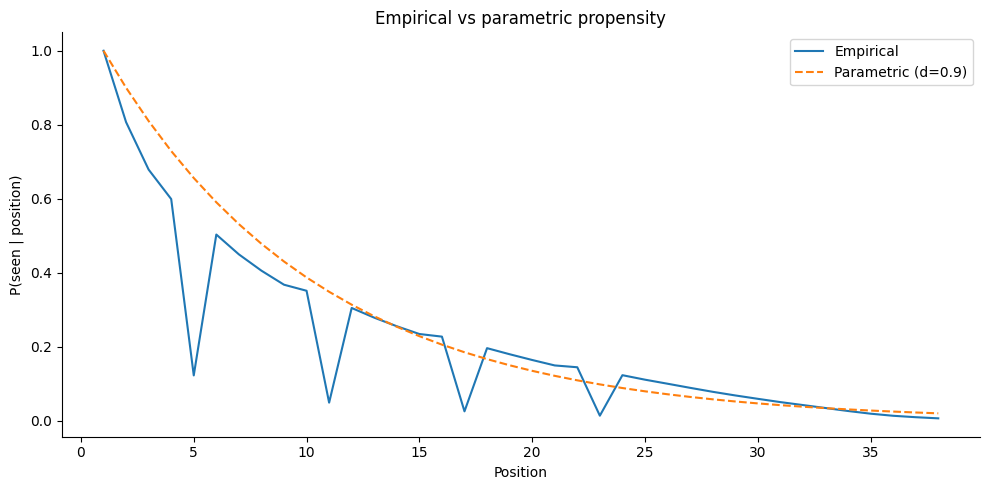

In [33]:
comparison = view_propensity.merge(parametric_propensity, on="position")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    comparison["position"], comparison["view_propensity"], label="Empirical"
)
ax.plot(
    comparison["position"],
    comparison["view_propensity_parametric"],
    label=f"Parametric (d={decay})",
    linestyle="--",
)
ax.set_xlabel("Position")
ax.set_ylabel("P(seen | position)")
ax.set_title("Empirical vs parametric propensity")
ax.legend()
sns.despine()
plt.tight_layout()

Now we can train the IPS model using the parametric decay propensities and see how it performs compared to the empirical IPS and the naive model.

In [34]:
train_df = train_df.merge(parametric_propensity, on="position", how="left")
test_df = test_df.merge(parametric_propensity, on="position", how="left")

config_param = IPSXGBoostConfig(
    label_column=TARGET,
    features=FEATURES,
    exposure_propensity_column="view_propensity_parametric",
)

ips_param_model = IPSXGBoostAdapter(config_param)
ips_param_model.fit(train_df)
test_df["ips_param_score"] = ips_param_model.predict(test_df)

Clipping 22476 IPS weights (1.0%) above the 99.0 percentile (clip value: 23.5898). Large clipping ratios may indicate poor propensity score calibration.


In [35]:
ips_param_ndcg = ndcg_at_k(
    test_df,
    query_col="srch_id",
    label_col=TARGET,
    score_col="ips_param_score",
    k=10,
)

ips_param_debiased_ndcg = debiased_ndcg_at_k(
    test_df,
    query_col="srch_id",
    label_col=TARGET,
    score_col="ips_param_score",
    propensity_col="view_propensity",
    k=10,
)

print(f"{'Model':<25} {'NDCG@10':>10} {'Debiased NDCG@10':>18}")
print("-" * 55)
print(f"{'Naive':<25} {naive_ndcg:>10.4f} {naive_debiased_ndcg:>18.4f}")
print(f"{'IPS (empirical)':<25} {ips_ndcg:>10.4f} {ips_debiased_ndcg:>18.4f}")
print(
    f"{'IPS (parametric)':<25} "
    f"{ips_param_ndcg:>10.4f} {ips_param_debiased_ndcg:>18.4f}"
)

Model                        NDCG@10   Debiased NDCG@10
-------------------------------------------------------
Naive                         0.6587             0.6587
IPS (empirical)               0.6614             0.6614
IPS (parametric)              0.6618             0.6618


For the moment the best approach is the parametric decay model, which has a better debiased NDCG@10 than the empirical IPS and the naive model. This suggests that the parametric model is providing a better bias correction, likely because it is less noisy at the tail positions where data is sparse. The empirical IPS may be overfitting to noise in those positions, while the parametric model provides a smoother estimate of propensities across all positions.

> Note that in real-world scenarios the logs data can have noise that makes the empirical propensities unreliable, especially at the tail. In those cases, a well-chosen parametric model can provide a more robust bias correction and lead to better downstream performance, even if it introduces some bias due to model misspecification. The key is to validate the parametric assumptions as much as possible and be aware of the tradeoffs involved.

## Bayesian shrinkage blend

Neither the empirical nor the parametric estimate is ideal on its own. The empirical one is noisy at sparse positions (high variance, low bias). The parametric one is smooth everywhere but wrong if the constant-dropout assumption doesn't hold (low variance, potentially high bias).

A Bayesian shrinkage blend interpolates between the two based on how much data we have at each position:

$$P(\text{seen} | k) = \lambda_k \cdot \hat{p}_k^{\text{emp}} + (1 - \lambda_k) \cdot \hat{p}_k^{\text{param}}$$

where the position-specific weight is:

$$\lambda_k = \frac{n_k}{n_k + n_0}$$

$n_k$ is the number of sessions that could have reached position $k$, and $n_0$ is a prior strength hyperparameter. When $n_k \gg n_0$, we trust the empirical estimate. When $n_k \ll n_0$, we fall back to the parametric prior. $n_0$ encodes how many "observations" the parametric model is worth — a higher $n_0$ means more skepticism toward the raw empirical counts.

In [36]:
session_counts = (
    df[["srch_id", "position"]]
    .drop_duplicates()
    .groupby("position")
    .size()
    .reset_index(name="n_k")
)

Before committing to $n_0 = 1000$, let's visualize how the blend and the shrinkage weight $\lambda_k$ behave across a range of $n_0$ values. The left panel shows how conservative each choice is on the propensity estimates. The right panel — the real calibration tool — shows at which positions we start trusting the empirical data for each $n_0$. Choose the smallest $n_0$ where the blend still looks stable in the tail.

### How to choose $n_0$

$n_0$ controls how many "virtual observations" the parametric prior is worth. The calibration plot shows the shape of the blend for different $n_0$ — but choosing among them requires a criterion, not eyeballing.

**The idea in plain terms:**

At each position, split the sessions randomly into two halves — a training half and a holdout half. Compute the reach rate from the training half, blend it with the parametric model, and see how well that blend predicts the reach rate from the holdout half. The loss is:

$$\text{loss}(n_0) = \sum_{\text{position}} \sqrt{\text{sessions at position}} \cdot \left(\text{blended reach rate from training half} - \text{reach rate from holdout half}\right)^2$$

where the blended reach rate from the training half is:

$$\text{blended reach rate} = \frac{\text{sessions in training half}}{\text{sessions in training half} + n_0} \cdot \text{empirical reach rate} + \frac{n_0}{\text{sessions in training half} + n_0} \cdot \text{parametric reach rate}$$

The $\sqrt{\text{sessions at position}}$ weight gives more importance to dense positions without completely ignoring the tail. Pick the $n_0$ that minimizes the loss.

**Why the split matters:** at dense positions the two halves agree regardless of $n_0$ — the empirical estimate is stable. At sparse positions the two halves disagree because a handful of extra or missing "reach" events flips the rate, and the blend with the right $n_0$ smooths that noise out by pulling toward the parametric prior.

---

**Formal notation:**
- $k$: position index (1 = first item shown, 2 = second, ...)
- $n_k$: number of sessions that could reach position $k$ — the exposure opportunity count
- $\hat{p}_k^{\text{emp}}$: empirical $P(\text{seen} \mid k)$, the raw reach rate computed from logs
- $\hat{p}_k^{\text{param}}$: parametric $P(\text{seen} \mid k) = d^{k-1}$, the dropout model estimate
- $\lambda_k = n_k / (n_k + n_0)$: per-position trust weight — how much we rely on the empirical estimate vs. the prior
- $n_0$: prior strength — how many virtual observations the parametric model is worth

The blend on fold A and the cross-validation loss are:

$$\hat{p}_k^{\text{blend}}(n_0) = \frac{n_k^A}{n_k^A + n_0} \cdot \hat{p}_k^A + \frac{n_0}{n_k^A + n_0} \cdot d^{k-1}$$

$$\mathcal{L}(n_0) = \sum_k \sqrt{n_k} \cdot \left(\hat{p}_k^{\text{blend}}(n_0) - \hat{p}_k^B\right)^2 \qquad n_0^* = \arg\min_{n_0} \mathcal{L}(n_0)$$

This maps directly to a `ShrinkageSelector` class with a `fit(empirical_propensity, session_counts, parametric_propensity)` method that sweeps $n_0$ over a log-spaced grid and returns the minimizer of $\mathcal{L}$.

With the default config and this dataset, the selector returns $n_0^* = 100$ — meaning the parametric model is worth only 100 virtual observations. Given that even the sparsest position has ~21k sessions, $\lambda_k$ stays above 0.99 everywhere. The cross-validation is effectively telling us the data is dense enough to trust the empirical estimates almost entirely, and the parametric model only fills in the very last bit of regularization.

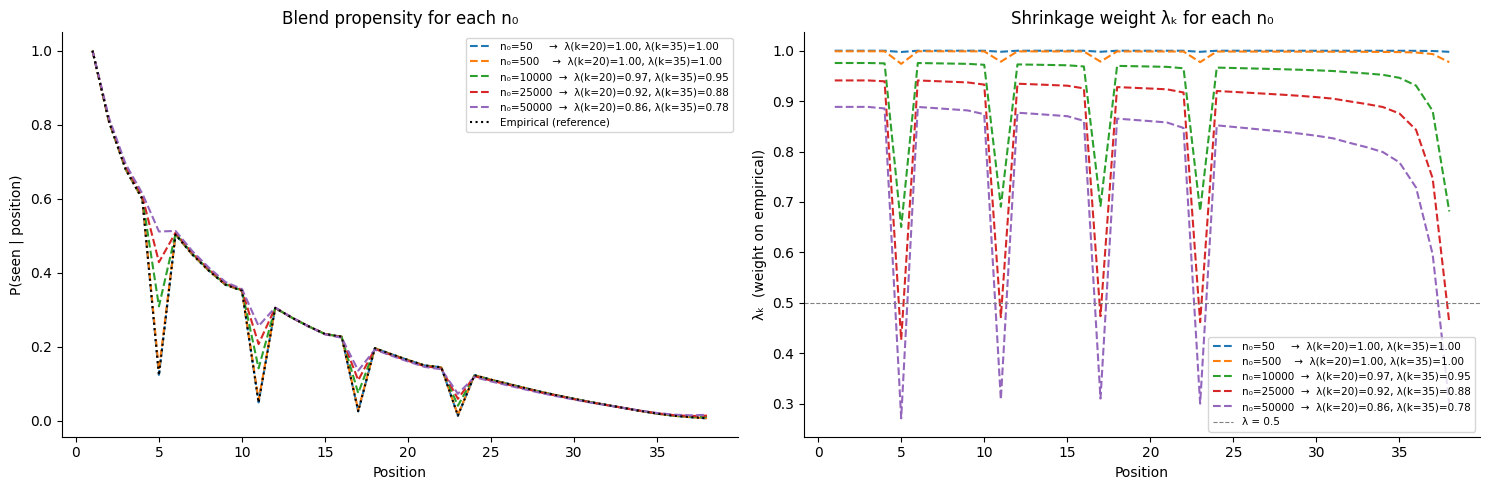

In [37]:
n0_candidates = [50, 500, 10_000, 25_000, 50_000]

calib_base = view_propensity.merge(parametric_propensity, on="position").merge(
    session_counts, on="position"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for n0_val in n0_candidates:
    lam = calib_base["n_k"] / (calib_base["n_k"] + n0_val)
    blend = (
        lam * calib_base["view_propensity"]
        + (1 - lam) * calib_base["view_propensity_parametric"]
    )

    lam_k20 = float(lam[calib_base["position"] == 20].iloc[0])
    lam_k35 = float(lam[calib_base["position"] == 35].iloc[0])
    label = f"n₀={n0_val:<5}  →  λ(k=20)={lam_k20:.2f}, λ(k=35)={lam_k35:.2f}"

    ax1.plot(calib_base["position"], blend, linestyle="--", label=label)
    ax2.plot(calib_base["position"], lam, linestyle="--", label=label)

ax1.plot(
    calib_base["position"],
    calib_base["view_propensity"],
    color="black",
    linewidth=1.5,
    linestyle=":",
    label="Empirical (reference)",
)
ax1.set_xlabel("Position")
ax1.set_ylabel("P(seen | position)")
ax1.set_title("Blend propensity for each n₀")
ax1.legend(fontsize=7.5)

ax2.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="λ = 0.5")
ax2.set_xlabel("Position")
ax2.set_ylabel("λₖ  (weight on empirical)")
ax2.set_title("Shrinkage weight λₖ for each n₀")
ax2.legend(fontsize=7.5)

sns.despine()
plt.tight_layout()

In [38]:
from unbiastap import ShrinkageSelector, ShrinkageSelectorConfig

blend_df = view_propensity.merge(parametric_propensity, on="position").merge(
    session_counts, on="position"
)

shrinkage_config = ShrinkageSelectorConfig(
    n0_min=100,
	n0_max=50_000,
    n_grid_points=100,
    random_seed=SEED,
)

shrinkage_selector = ShrinkageSelector(shrinkage_config)
shrinkage_selector.fit(
    empirical_propensity=blend_df["view_propensity"].to_numpy(),
    session_counts=blend_df["n_k"].to_numpy(),
    parametric_propensity=blend_df["view_propensity_parametric"].to_numpy(),
)

print(f"Optimal prior strength: n0* = {shrinkage_selector.n0_star_:.0f}")

blend_df["lambda_k"] = shrinkage_selector._shrinkage_weight(
    blend_df["n_k"].to_numpy(), shrinkage_selector.n0_star_
)
blend_df["view_propensity_blend"] = shrinkage_selector.blend(
    empirical_propensity=blend_df["view_propensity"].to_numpy(),
    session_counts=blend_df["n_k"].to_numpy(),
    parametric_propensity=blend_df["view_propensity_parametric"].to_numpy(),
)

blend_df[
    ["position", "n_k", "lambda_k", "view_propensity", "view_propensity_parametric", "view_propensity_blend"]
].round(3)

Optimal prior strength: n0* = 100


,position,n_k,lambda_k,view_propensity,view_propensity_parametric,view_propensity_blend
0,1,398569,1.000,1.000,1.000,1.000
1,2,398466,1.000,0.807,0.900,0.807
2,3,398484,1.000,0.679,0.810,0.679
3,4,386427,1.000,0.599,0.729,0.599
4,5,18600,0.995,0.123,0.656,0.126
...,...,...,...,...,...,...
33,34,198733,0.999,0.027,0.031,0.027
34,35,175726,0.999,0.019,0.028,0.019
35,36,134277,0.999,0.014,0.025,0.014
36,37,73813,0.999,0.010,0.023,0.010


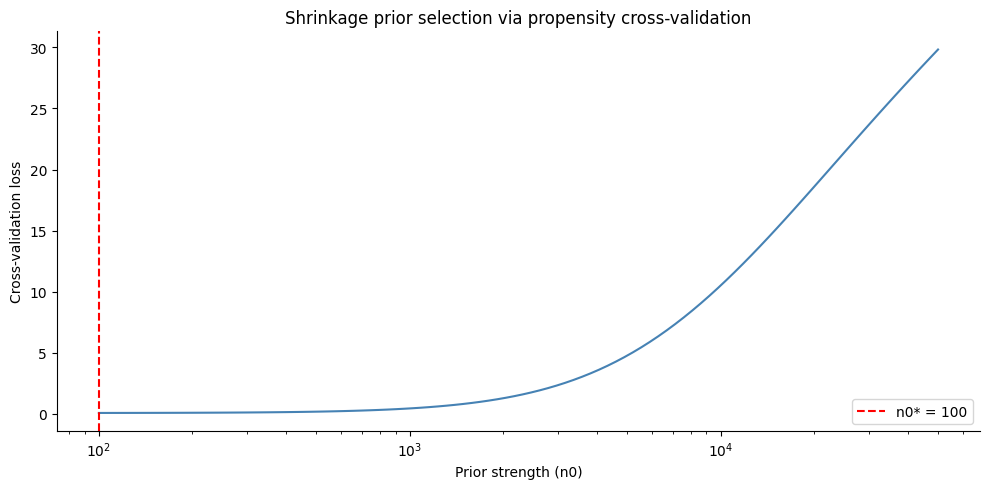

In [39]:
fig = shrinkage_selector.plot_loss_curve()

In [40]:
n0 = 100

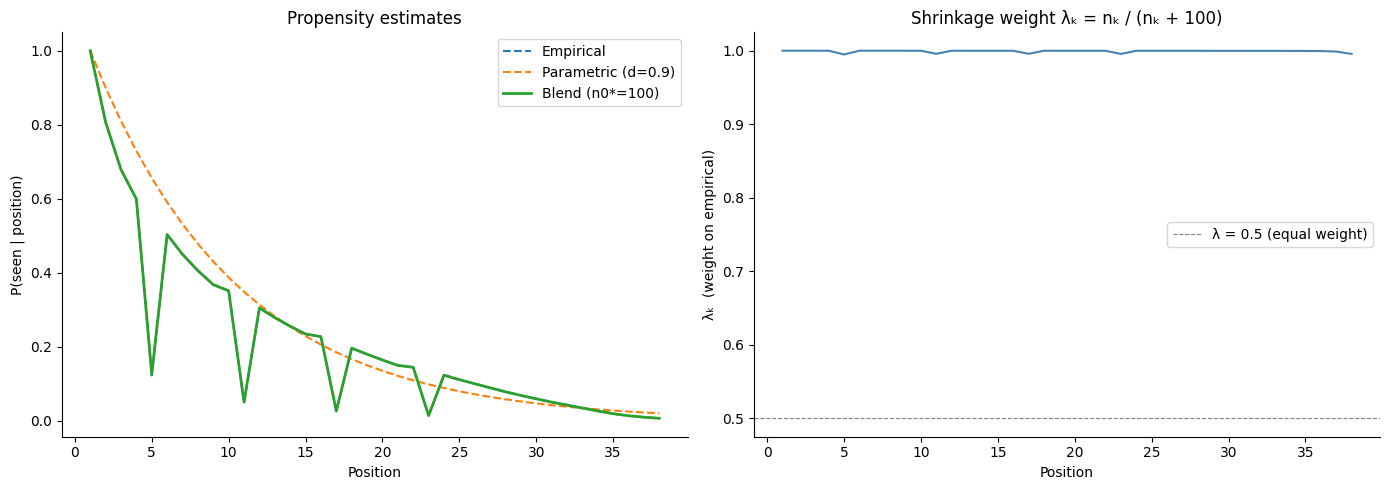

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(
    blend_df["position"],
    blend_df["view_propensity"],
    label="Empirical",
    linestyle="--",
)
ax1.plot(
    blend_df["position"],
    blend_df["view_propensity_parametric"],
    label=f"Parametric (d={decay})",
    linestyle="--",
)
ax1.plot(
    blend_df["position"],
    blend_df["view_propensity_blend"],
    label=f"Blend (n0*={shrinkage_selector.n0_star_:.0f})",
    linewidth=2,
)
ax1.set_xlabel("Position")
ax1.set_ylabel("P(seen | position)")
ax1.set_title("Propensity estimates")
ax1.legend()

ax2.plot(blend_df["position"], blend_df["lambda_k"], color="steelblue")
ax2.axhline(
    0.5,
    color="gray",
    linestyle="--",
    linewidth=0.8,
    label="λ = 0.5 (equal weight)",
)
ax2.set_xlabel("Position")
ax2.set_ylabel("λₖ  (weight on empirical)")
ax2.set_title(f"Shrinkage weight λₖ = nₖ / (nₖ + {n0})")
ax2.legend()

sns.despine()
plt.tight_layout()

The right panel is the key diagnostic: where $\lambda_k$ is close to 1, we're almost fully trusting the empirical estimate (dense positions). Where it drops below 0.5, the parametric prior dominates. $n_0 = 1000$ means a position needs at least 1000 observed sessions before we give the empirical estimate half the weight. Increase $n_0$ to be more conservative; decrease it to trust the data earlier in the tail.

In [42]:
blend_propensity = blend_df[["position", "view_propensity_blend"]]

train_df = train_df.merge(blend_propensity, on="position", how="left")
test_df = test_df.merge(blend_propensity, on="position", how="left")

config_blend = IPSXGBoostConfig(
    label_column=TARGET,
    features=FEATURES,
    exposure_propensity_column="view_propensity_blend",
)

ips_blend_model = IPSXGBoostAdapter(config_blend)
ips_blend_model.fit(train_df)
test_df["ips_blend_score"] = ips_blend_model.predict(test_df)

Clipping 23173 IPS weights (1.0%) above the 99.0 percentile (clip value: 19.8142). Large clipping ratios may indicate poor propensity score calibration.


In [43]:
ips_blend_ndcg = ndcg_at_k(
    test_df,
    query_col="srch_id",
    label_col=TARGET,
    score_col="ips_blend_score",
    k=10,
)

ips_blend_debiased_ndcg = debiased_ndcg_at_k(
    test_df,
    query_col="srch_id",
    label_col=TARGET,
    score_col="ips_blend_score",
    propensity_col="view_propensity",
    k=10,
)

print(f"{'Model':<30} {'NDCG@10':>10} {'Debiased NDCG@10':>18}")
print("-" * 60)
print(f"{'Naive':<30} {naive_ndcg:>10.4f} {naive_debiased_ndcg:>18.4f}")
print(f"{'IPS (empirical)':<30} {ips_ndcg:>10.4f} {ips_debiased_ndcg:>18.4f}")
print(
    f"{'IPS (parametric)':<30} "
    f"{ips_param_ndcg:>10.4f} {ips_param_debiased_ndcg:>18.4f}"
)
print(
    f"{'IPS (blend, n₀=' + str(n0) + ')':<30} "
    f"{ips_blend_ndcg:>10.4f} {ips_blend_debiased_ndcg:>18.4f}"
)

Model                             NDCG@10   Debiased NDCG@10
------------------------------------------------------------
Naive                              0.6587             0.6587
IPS (empirical)                    0.6614             0.6614
IPS (parametric)                   0.6618             0.6618
IPS (blend, n₀=100)                0.6619             0.6619
